In [9]:
# %% [markdown]
# # INFO-F-422 Project: Freemoves Gestures EMG Regression (Definitive Version)
#
# This notebook processes the **Free Gestures** dataset.
# Methodology for filtering, windowing, feature extraction, CV, SFS, modeling,
# and ensembling is designed to be structurally identical to a corresponding
# Guided Gestures notebook, differing only in data and results.

# %% [markdown]
# ## 1. Setup & Imports

# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import pickle
import gc
from contextlib import contextmanager
from pathlib import Path

# Scikit-learn
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.model_selection import GroupKFold, cross_validate, train_test_split, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, make_scorer
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.exceptions import NotFittedError

# Scipy
from scipy.signal import butter, filtfilt, iirnotch, freqz
import scipy.fftpack

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset

# Set random seed for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Device configuration (Force CPU as per user request)
device = torch.device("cpu")
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # Original for auto-detection
print(f"Using device: {device} (CPU forced as per request)")

# Matplotlib style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('notebook')

# Pandas display options
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)


Using device: cpu (CPU forced as per request)


In [11]:

# %% [markdown]
# ## 2. Configuration

# %%
# --- Data Paths ---
DATA_DIR = Path(".")

# --- Freemoves Data Files ---
X_TRAIN_VAL_PATH_FREEMOVES = DATA_DIR / "freemoves_dataset_X.npy"
Y_TRAIN_VAL_PATH_FREEMOVES = DATA_DIR / "freemoves_dataset_y.npy"
X_TEST_PATH_FREEMOVES = DATA_DIR / "freemoves_testset_X.npy"

# --- Guided Predictions Path (Needed for Final Submission) ---
OUTPUT_DIR = Path("output")
# This file MUST be generated by running the GUIDED gestures notebook first
FINAL_GUIDED_PREDICTIONS_PATH = OUTPUT_DIR / "guided_predictions.npy"

# --- Output Paths for Freemoves ---
OUTPUT_DIR.mkdir(exist_ok=True)
FINAL_FREEMOVES_PREDICTIONS_PATH = OUTPUT_DIR / "freemoves_predictions.npy"
FINAL_SUBMISSION_CSV_PATH = OUTPUT_DIR / "team_submission.csv"

# --- Model Saving Directory for Freemoves ---
MODEL_SAVE_DIR = Path("saved_models_freemoves")
MODEL_SAVE_DIR.mkdir(exist_ok=True)

# --- Preprocessing Parameters ---
# --- Preprocessing Parameters ---
FS = 1024
FILTER_LOWCUT = 20
FILTER_HIGHCUT = 450
FILTER_ORDER = 5
APPLY_FILTERING = True
NOTCH_FREQ = 50  
QUALITY_FACTOR = 30  

# --- Windowing Parameters ---
WINDOW_SIZE = 500
OVERLAP_PERCENTAGE = 0.75

# --- Feature Extraction Parameters ---
ZC_THRESHOLD = 1e-5
SSC_THRESHOLD = 1e-5

# --- Model Hyperparameters (Initial values, may be tuned) ---
RIDGE_ALPHA = 1.0
LASSO_ALPHA = 0.01
LASSO_MAX_ITER = 3000
LASSO_TOL = 1e-4
RF_N_ESTIMATORS = 100
RF_MAX_DEPTH = 15
RF_MAX_FEATURES = 0.33
RF_RANDOM_STATE = SEED

NN_MAX_EPOCHS = 150
NN_BATCH_SIZE = 256
NN_LR = 1e-3
NN_WEIGHT_DECAY = 5e-5
NN_PATIENCE_LR = 12
NN_PATIENCE_ES = 20 # Freemoves might benefit from more patience

SFS_N_FEATURES = 'auto'
SFS_TOL = 1e-4
SFS_DIRECTION = 'forward'

META_RIDGE_ALPHA = 1.0
META_RF_N_ESTIMATORS = 50
META_RF_MAX_DEPTH = 5

# %% [markdown]
# ## 3. Helper Functions & Classes (Identical to Guided Version)

# %%
@contextmanager
def timer(label: str):
    start = time.time(); yield; end = time.time(); print(f"{label}: {end - start:.2f} seconds")

def root_mean_squared_error(y_true, y_pred): return np.sqrt(mean_squared_error(y_true, y_pred))
def normalized_mean_squared_error(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    if y_true.shape != y_pred.shape: raise ValueError(f"Shape mismatch: y_true {y_true.shape}, y_pred {y_pred.shape}")
    if y_true.ndim == 1: y_true, y_pred = y_true.reshape(-1, 1), y_pred.reshape(-1, 1)
    numerator = np.sum((y_true - y_pred)**2, axis=0); mean_y_true_per_joint = np.mean(y_true, axis=0)
    denominator = np.sum((y_true - mean_y_true_per_joint)**2, axis=0); mask = denominator > 1e-9
    nmse_per_joint = np.full_like(denominator, np.inf); nmse_per_joint[mask] = numerator[mask] / denominator[mask]
    nmse_per_joint[denominator <= 1e-9] = 0.0; return np.mean(nmse_per_joint)

scorers = {'rmse': make_scorer(root_mean_squared_error, greater_is_better=False),
           'nmse': make_scorer(normalized_mean_squared_error, greater_is_better=False),
           'r2': make_scorer(r2_score)}

def butter_bandpass(lowcut, highcut, fs, order=5):
     nyq=0.5*fs; low=lowcut/nyq; high=highcut/nyq
     if low<=0 or high>=1 or low>=high: raise ValueError("Invalid cutoff frequencies")
     b,a=butter(order,[low,high],btype='band'); return b,a
def bandpass_filter(data,lowcut,highcut,fs,order=5):
     b,a=butter_bandpass(lowcut,highcut,fs,order=order); return filtfilt(b,a,data,axis=-1)
def apply_notch_filter(data, notch_freq, quality_factor, fs):
    """Apply IIR notch filter to remove specific frequency noise."""
    nyq = 0.5 * fs
    notch_freq_normalized = notch_freq / nyq
    b_notch, a_notch = iirnotch(notch_freq_normalized, quality_factor)
    y = filtfilt(b_notch, a_notch, data, axis=-1)
    return y

def create_overlapping_windows(X_raw, y_raw, window_size, step):
    n_s,n_e,n_t=X_raw.shape; n_j=y_raw.shape[1] if y_raw is not None else 0
    X_w_list,y_w_list,g_list,w_indices_list = [],[],[],[]
    print(f"Creating windows: size={window_size}, step={step}"); tot_w=0
    for s_idx in range(n_s):
        s_X=X_raw[s_idx]; s_y=y_raw[s_idx] if y_raw is not None else None
        start_indices_arr=np.arange(0,n_t-window_size+1,step); s_w_count=0
        for st_idx in start_indices_arr:
            e_idx=st_idx+window_size; X_w_list.append(s_X[:,st_idx:e_idx])
            if s_y is not None: y_w_list.append(s_y[:,e_idx-1]) # Target is at the end of the EMG window
            g_list.append(s_idx); w_indices_list.append((s_idx,st_idx,e_idx)); s_w_count+=1; tot_w+=1
        print(f"  Session {s_idx}: Created {s_w_count} windows.")
    print(f"Total windows created: {tot_w}")
    return np.stack(X_w_list), (np.stack(y_w_list) if y_raw is not None else None), np.array(g_list), w_indices_list

def plot_cv_indices(cv,X,y,group,n_splits_val,ax_obj): # Renamed for clarity
    cm_data=plt.cm.Paired; cm_cv_plot=plt.cm.coolwarm
    for i,(tr_idx,te_idx) in enumerate(cv.split(X,y,group)):
        indices_arr=np.array([np.nan]*len(X)); indices_arr[te_idx]=1; indices_arr[tr_idx]=0
        ax_obj.scatter(range(len(indices_arr)),[i+.5]*len(indices_arr),c=indices_arr,marker='_',lw=10,cmap=cm_cv_plot,vmin=-.2,vmax=1.2)
    ax_obj.scatter(range(len(X)),[i+1.5]*len(X),c=group,marker='_',lw=10,cmap=cm_data) # Plot group after loop for correct 'i'
    ytl_plot=list(range(n_splits_val))+['Session']
    ax_obj.set(yticks=np.arange(n_splits_val+1)+.5,yticklabels=ytl_plot,xlabel='Sample Index',ylabel="CV Fold / Session",ylim=[n_splits_val+1.2,-.2],xlim=[0,len(y)])
    ax_obj.set_title(f'{type(cv).__name__} Splits',fontsize=12)

class EarlyStop:
    def __init__(self,patience=10,delta=1e-4):self.patience=patience;self.delta=delta;self.best_score=float('inf');self.counter=0
    def __call__(self,score_val):
        if score_val<self.best_score-self.delta:self.best_score=score_val;self.counter=0;return False
        else:self.counter+=1;return self.counter>=self.patience
def train_nn_epoch(model_obj,loader_obj,crit_obj,opt_obj,dev_obj):
    model_obj.train();running_loss_val=0.0
    for inputs_val,targets_val in loader_obj:
        inputs_val,targets_val=inputs_val.to(dev_obj),targets_val.to(dev_obj);opt_obj.zero_grad()
        outputs_val=model_obj(inputs_val);loss_val=crit_obj(outputs_val,targets_val)
        loss_val.backward();opt_obj.step();running_loss_val+=loss_val.item()*inputs_val.size(0)
    return running_loss_val/len(loader_obj.dataset)
def evaluate_nn_model(model_obj,loader_obj,crit_obj,dev_obj):
    model_obj.eval();running_loss_val=0.0;all_preds_list,all_targets_list=[],[]
    with torch.no_grad():
        for inputs_val,targets_val in loader_obj:
            inputs_val,targets_val=inputs_val.to(dev_obj),targets_val.to(dev_obj)
            outputs_val=model_obj(inputs_val);loss_val=crit_obj(outputs_val,targets_val)
            running_loss_val+=loss_val.item()*inputs_val.size(0)
            all_preds_list.append(outputs_val.cpu().numpy());all_targets_list.append(targets_val.cpu().numpy())
    avg_loss_val=running_loss_val/len(loader_obj.dataset)
    return avg_loss_val,np.concatenate(all_preds_list),np.concatenate(all_targets_list)

class EMGFeatureExtractor(BaseEstimator, TransformerMixin):
    def __init__(self, zc_thresh=1e-5, ssc_thresh=1e-5, sel_feat=None, fs=1024, verb=False):
        self.zc_thresh = zc_thresh; self.ssc_thresh = ssc_thresh; self.sel_feat = sel_feat
        self.fs = fs; self.verb = verb
        self.all_avail_fn = sorted(['MAV','RMS','Var','STD','ZC','MPR','WL','SSC','IEMG','MNF','MDF'])
        self.n_elec = None
    def _resolve_feat_ext(self):
        if self.sel_feat is None: return self.all_avail_fn
        else:
            cs_list = list(self.sel_feat)
            for f_n in cs_list:
                if f_n not in self.all_avail_fn: raise ValueError(f"Invalid feature '{f_n}'.")
            return sorted(list(set(cs_list)))
    def fit(self, X_data, y_data=None):
        if X_data.ndim != 3: raise ValueError(f"Input X must be 3D. Got shape {X_data.shape}")
        self.n_elec = X_data.shape[1]
        self._actual_feat_ext = self._resolve_feat_ext()
        if self.verb: print(f"Extractor fit. Features: {self._actual_feat_ext}")
        return self
    def transform(self, X_data):
        if self.n_elec is None or not hasattr(self,'_actual_feat_ext'): raise NotFittedError("Call 'fit' first.")
        if X_data.ndim != 3 or X_data.shape[1] != self.n_elec: raise ValueError("Input X shape inconsistent.")
        n_windows,n_electrodes,win_size = X_data.shape; n_selected_feats = len(self._actual_feat_ext)
        if n_selected_feats == 0:
            if self.verb: print("Warning: No features to extract.")
            return np.empty((n_windows, 0))
        features_mat = np.zeros((n_windows, n_electrodes * n_selected_feats))
        freqs_arr = np.fft.rfftfreq(win_size, d=1/self.fs)
        for i_win in range(n_windows):
            win_feats_list = []
            for j_elec in range(n_electrodes):
                chan_data = X_data[i_win, j_elec, :]; chan_feats_dict = {}
                abs_chan_data = np.abs(chan_data); diff_chan_data = np.diff(chan_data)
                chan_feats_dict['MAV']=np.mean(abs_chan_data); chan_feats_dict['RMS']=np.sqrt(np.mean(chan_data**2))
                chan_feats_dict['Var']=np.var(chan_data); chan_feats_dict['STD']=np.sqrt(chan_feats_dict['Var']) if chan_feats_dict['Var']>=0 else 0
                chan_feats_dict['IEMG']=np.sum(abs_chan_data); chan_feats_dict['WL']=np.sum(np.abs(diff_chan_data))
                chan_feats_dict['ZC']=np.sum(np.diff(np.signbit(chan_data - self.zc_thresh)).astype(bool))
                ssc_c1=(diff_chan_data[:-1]>self.ssc_thresh)&(diff_chan_data[1:]<-self.ssc_thresh)
                ssc_c2=(diff_chan_data[:-1]<-self.ssc_thresh)&(diff_chan_data[1:]>self.ssc_thresh)
                chan_feats_dict['SSC']=np.sum(ssc_c1|ssc_c2)
                mpr_threshold_val=chan_feats_dict['STD']; mpr_threshold_val=max(mpr_threshold_val,1e-9)
                chan_feats_dict['MPR']=np.mean(abs_chan_data > mpr_threshold_val)
                power_spec_val=np.abs(np.fft.rfft(chan_data))**2; total_power_val=np.sum(power_spec_val)
                if total_power_val > 1e-9:
                    chan_feats_dict['MNF']=np.sum(freqs_arr*power_spec_val)/total_power_val
                    cum_power_val=np.cumsum(power_spec_val); mdf_idx_val=np.searchsorted(cum_power_val,total_power_val/2.,side='left')
                    chan_feats_dict['MDF']=freqs_arr[mdf_idx_val] if mdf_idx_val<len(freqs_arr) else freqs_arr[-1]
                else: chan_feats_dict['MNF']=0.; chan_feats_dict['MDF']=0.
                for feat_n_val in self._actual_feat_ext: win_feats_list.append(chan_feats_dict.get(feat_n_val,0.))
            features_mat[i_win,:] = win_feats_list
        return np.nan_to_num(features_mat,nan=0.,posinf=0.,neginf=0.)
    def get_feature_names_out(self, input_features=None):
        if self.n_elec is None or not hasattr(self,'_actual_feat_ext'): raise NotFittedError("Call 'fit' first.")
        return [f"Elec{j+1}_{feat_n}" for j in range(self.n_elec) for feat_n in self._actual_feat_ext]

class EMG_NN(nn.Module):
    def __init__(self,n_features_in,n_joints_out,hidden_config=(256,128,64),dropout_prob=0.2): # Consistent param names
        super().__init__();h1,h2,h3=hidden_config;layer_list=[];current_features=n_features_in
        layer_list.extend([nn.Linear(current_features,h1),nn.BatchNorm1d(h1),nn.ReLU(),nn.Dropout(dropout_prob)]);current_features=h1
        layer_list.extend([nn.Linear(current_features,h2),nn.BatchNorm1d(h2),nn.ReLU(),nn.Dropout(dropout_prob)]);current_features=h2
        layer_list.extend([nn.Linear(current_features,h3),nn.BatchNorm1d(h3),nn.ReLU(),nn.Dropout(dropout_prob)]);current_features=h3
        layer_list.append(nn.Linear(current_features,n_joints_out));self.network_seq=nn.Sequential(*layer_list) # Use unique attribute name
    def forward(self,x_input):return self.network_seq(x_input)

def perform_nn_cv_oof(X_feats_nn,y_target_nn,groups_for_cv,cv_splitter,nn_config_dict,device_to_use):
    oof_predictions_arr=np.zeros_like(y_target_nn,dtype=float)
    fold_metrics_dict={'rmse':[],'nmse':[],'r2':[],'fit_time':[],'score_time':[]}
    n_cv_splits=cv_splitter.get_n_splits()
    for k_fold_idx,(train_indices,val_indices) in enumerate(cv_splitter.split(X_feats_nn,y_target_nn,groups=groups_for_cv)):
        fold_start_t=time.time(); print(f"  NN CV Fold {k_fold_idx+1}/{n_cv_splits}")
        X_train_fold,X_val_fold=X_feats_nn[train_indices],X_feats_nn[val_indices]
        y_train_fold,y_val_fold=y_target_nn[train_indices],y_target_nn[val_indices]
        scaler_fold=StandardScaler(); X_train_scaled=scaler_fold.fit_transform(X_train_fold); X_val_scaled=scaler_fold.transform(X_val_fold)
        ds_train_fold=TensorDataset(torch.tensor(X_train_scaled).float(),torch.tensor(y_train_fold).float())
        ds_val_fold=TensorDataset(torch.tensor(X_val_scaled).float(),torch.tensor(y_val_fold).float())
        loader_train_fold=DataLoader(ds_train_fold,batch_size=nn_config_dict['batch_size'],shuffle=True,num_workers=2,pin_memory=False) # CPU: pin_memory=False
        loader_val_fold=DataLoader(ds_val_fold,batch_size=nn_config_dict['batch_size']*2,shuffle=False,num_workers=2,pin_memory=False)
        nn_model_fold = EMG_NN(X_train_scaled.shape[1], y_train_fold.shape[1],
                               hidden_config=nn_config_dict['hidden'], dropout_prob=nn_config_dict['dropout']).to(device_to_use)
        criterion_fold=nn.MSELoss(); optimizer_fold=optim.Adam(nn_model_fold.parameters(),lr=nn_config_dict['lr'],weight_decay=nn_config_dict['weight_decay'])
        scheduler_fold=optim.lr_scheduler.ReduceLROnPlateau(optimizer_fold,mode='min',factor=0.5,patience=nn_config_dict['patience_lr'],verbose=False)
        early_stopper_fold=EarlyStop(patience=nn_config_dict['patience_es'])
        for epoch_idx in range(nn_config_dict['max_epochs']):
            train_nn_epoch(nn_model_fold,loader_train_fold,criterion_fold,optimizer_fold,device_to_use)
            mse_val_fold,_,_=evaluate_nn_model(nn_model_fold,loader_val_fold,criterion_fold,device_to_use)
            scheduler_fold.step(mse_val_fold)
            if early_stopper_fold(mse_val_fold): print(f"    Fold {k_fold_idx+1} early stopping at epoch {epoch_idx+1}"); break
        fit_time_val=time.time()-fold_start_t
        val_mse_final,fold_preds_arr,fold_targets_arr=evaluate_nn_model(nn_model_fold,loader_val_fold,criterion_fold,device_to_use)
        score_time_val=(time.time()-fold_start_t)-fit_time_val
        oof_predictions_arr[val_indices]=fold_preds_arr
        fold_metrics_dict['rmse'].append(np.sqrt(val_mse_final)); fold_metrics_dict['nmse'].append(normalized_mean_squared_error(fold_targets_arr,fold_preds_arr))
        fold_metrics_dict['r2'].append(r2_score(fold_targets_arr,fold_preds_arr)); fold_metrics_dict['fit_time'].append(fit_time_val); fold_metrics_dict['score_time'].append(score_time_val)
        del nn_model_fold,optimizer_fold,scheduler_fold,early_stopper_fold,loader_train_fold,loader_val_fold,ds_train_fold,ds_val_fold; gc.collect(); torch.cuda.empty_cache()
    cv_scores_dict={'test_rmse':-np.array(fold_metrics_dict['rmse']),'test_nmse':-np.array(fold_metrics_dict['nmse']),
                    'test_r2':np.array(fold_metrics_dict['r2']),'fit_time':np.array(fold_metrics_dict['fit_time']),
                    'score_time':np.array(fold_metrics_dict['score_time'])}; return oof_predictions_arr,cv_scores_dict

def predict_with_final_model(model_package_dict,X_test_raw_windows_arr):
    model_type_str = model_package_dict.get('model_type',None) if isinstance(model_package_dict,dict) else 'Pipeline'
    print(f"Predicting with: {model_type_str} ({model_package_dict.get('name','')})")
    n_test_windows_val=X_test_raw_windows_arr.shape[0]
    predictions_arr=np.zeros((n_test_windows_val,N_JOINTS)) # N_JOINTS global
    if model_type_str=='Pipeline' or isinstance(model_package_dict,Pipeline):
        with timer("Pipeline predict"):predictions_arr=model_package_dict.predict(X_test_raw_windows_arr)
    elif model_type_str=="NeuralNetwork": # Consistent name
        nn_model_obj=model_package_dict['model'].to(device); nn_scaler_obj=model_package_dict['scaler']
        nn_feat_extractor=model_package_dict['feature_extractor']; nn_model_obj.eval()
        with timer("NN Feat Extract (Test)"):X_test_feats_arr=nn_feat_extractor.transform(X_test_raw_windows_arr)
        with timer("NN Feat Scale (Test)"):X_test_feats_scaled_arr=nn_scaler_obj.transform(X_test_feats_arr)
        test_dataset_obj=TensorDataset(torch.tensor(X_test_feats_scaled_arr).float())
        test_loader_obj=DataLoader(test_dataset_obj,batch_size=NN_BATCH_SIZE*4,shuffle=False,num_workers=2,pin_memory=False) # CPU: pin_memory=False
        pred_list_vals=[]
        with torch.no_grad(),timer("NN predict (Test)"):
            for batch_data_val in test_loader_obj:
                inputs_data=batch_data_val[0].to(device); outputs_data=nn_model_obj(inputs_data); pred_list_vals.append(outputs_data.cpu().numpy())
        predictions_arr=np.concatenate(pred_list_vals)
    elif model_type_str=='AverageEnsemble':
        base_model_preds_dict={}; print("Predicting with base models for Averaging:")
        with timer("Avg Ens Base predict"):
            for model_name_str,base_model_pkg_val in model_package_dict['base_models_trained'].items():
                print(f"  Base: {model_name_str}"); base_model_preds_dict[model_name_str]=predict_with_final_model(base_model_pkg_val,X_test_raw_windows_arr)
        predictions_arr=np.mean(list(base_model_preds_dict.values()),axis=0)
    elif model_type_str=='StackingEnsemble':
        base_model_preds_list_vals=[]; print("Predicting with base models for Stacking:")
        with timer("Stack Ens Base predict"):
            for model_name_str in model_package_dict['base_model_order']: # Critical: Use defined order
                print(f"  Base: {model_name_str}"); base_model_pkg_val=model_package_dict['base_models_trained'][model_name_str]
                preds_val=predict_with_final_model(base_model_pkg_val,X_test_raw_windows_arr); base_model_preds_list_vals.append(preds_val)
        X_meta_test_arr=np.hstack(base_model_preds_list_vals); print(f"Test meta-features shape: {X_meta_test_arr.shape}")
        meta_model_obj=model_package_dict['meta_model']
        with timer("Stack Ens Meta predict"): predictions_arr=meta_model_obj.predict(X_meta_test_arr)
    else: raise TypeError(f"Unsupported final model type for prediction: {model_type_str}")
    if predictions_arr.shape!=(n_test_windows_val,N_JOINTS): raise ValueError("Prediction shape mismatch.")
    return predictions_arr

# %% [markdown]
# ## 4. Data Loading (Freemoves)

# %%
with timer("Loading Freemoves Train/Val Data"):
    if not X_TRAIN_VAL_PATH_FREEMOVES.exists() or not Y_TRAIN_VAL_PATH_FREEMOVES.exists(): # Use specific var names
        raise FileNotFoundError(f"Freemoves train/val files not found. Check paths in Section 2.")
    X_train_val_raw_freemoves = np.load(X_TRAIN_VAL_PATH_FREEMOVES)
    y_train_val_raw_freemoves = np.load(Y_TRAIN_VAL_PATH_FREEMOVES)
if not X_TEST_PATH_FREEMOVES.exists(): raise FileNotFoundError(f"Freemoves test file not found.")
X_test_raw_info_freemoves = np.load(X_TEST_PATH_FREEMOVES, mmap_mode='r')

print("\nRaw Freemoves Train/Val Shapes:"); print(f"X: {X_train_val_raw_freemoves.shape}, y: {y_train_val_raw_freemoves.shape}")
print(f"Raw Freemoves Test Shape (info): {X_test_raw_info_freemoves.shape}")

N_SESSIONS_TRAIN_VAL_FREEMOVES=X_train_val_raw_freemoves.shape[0]
N_ELECTRODES_FREEMOVES=X_train_val_raw_freemoves.shape[1] # Should be same as guided
N_TIME_POINTS_TRAIN_VAL_FREEMOVES=X_train_val_raw_freemoves.shape[2]
N_JOINTS_FREEMOVES=y_train_val_raw_freemoves.shape[1] # Should be same as guided

# Assert N_ELECTRODES and N_JOINTS are consistent if you plan to reuse models trained on guided
# For this notebook, we'll use N_ELECTRODES_FREEMOVES and N_JOINTS_FREEMOVES
print(f"\nFreemoves Sessions: {N_SESSIONS_TRAIN_VAL_FREEMOVES}, Electrodes: {N_ELECTRODES_FREEMOVES}, Time/Session: {N_TIME_POINTS_TRAIN_VAL_FREEMOVES}, Joints: {N_JOINTS_FREEMOVES}")
# Global N_JOINTS for predict_with_final_model
N_JOINTS = N_JOINTS_FREEMOVES


# %% [markdown]
# ## 5. Signal Filtering

# %%
X_train_val_to_window_freemoves = X_train_val_raw_freemoves # Assign to a new var for freemoves
if APPLY_FILTERING:
    with timer("Filtering Freemoves Data"):
        X_train_val_filtered_freemoves = np.zeros_like(X_train_val_raw_freemoves)
        for i in range(N_SESSIONS_TRAIN_VAL_FREEMOVES):
            # Remove DC offset (mean) per channel
            dc_removed = X_train_val_raw_freemoves[i] - np.mean(X_train_val_raw_freemoves[i], axis=-1, keepdims=True)
            
            # Apply notch filter first to remove power line interference
            notch_filtered = np.zeros_like(dc_removed)
            for j in range(dc_removed.shape[0]):  # For each electrode
                notch_filtered[j] = apply_notch_filter(dc_removed[j], NOTCH_FREQ, QUALITY_FACTOR, FS)
            
            # Then apply bandpass filter
            X_train_val_filtered_freemoves[i] = bandpass_filter(notch_filtered, FILTER_LOWCUT, FILTER_HIGHCUT, FS, order=FILTER_ORDER)
            
        X_train_val_to_window_freemoves = X_train_val_filtered_freemoves
        print("Applied DC offset removal, notch filtering (50 Hz), and bandpass filtering to Freemoves data.")
else: 
    print("Filtering skipped for Freemoves data.")


# %% [markdown]
# ## 6. Dataset Preparation: Overlapping Windows (Objective 2)

# %%
step_freemoves = int(WINDOW_SIZE*(1-OVERLAP_PERCENTAGE)); # Can be same step
if step_freemoves<=0: raise ValueError("Invalid step size.")
with timer("Windowing Freemoves Data"):
    X_windowed_freemoves,y_windowed_freemoves,groups_freemoves,_ = create_overlapping_windows(
        X_train_val_to_window_freemoves, y_train_val_raw_freemoves, WINDOW_SIZE, step_freemoves
    )
print(f"\nWindowed Freemoves Shapes: X_w: {X_windowed_freemoves.shape}, y_w: {y_windowed_freemoves.shape}, groups: {groups_freemoves.shape}")
print(f"Unique groups (Freemoves): {np.unique(groups_freemoves)}")

Loading Freemoves Train/Val Data: 1.76 seconds

Raw Freemoves Train/Val Shapes:
X: (5, 8, 270000), y: (5, 51, 270000)
Raw Freemoves Test Shape (info): (5, 308, 8, 500)

Freemoves Sessions: 5, Electrodes: 8, Time/Session: 270000, Joints: 51
Applied DC offset removal, notch filtering (50 Hz), and bandpass filtering to Freemoves data.
Filtering Freemoves Data: 1.18 seconds
Creating windows: size=500, step=125
  Session 0: Created 2157 windows.
  Session 1: Created 2157 windows.
  Session 2: Created 2157 windows.
  Session 3: Created 2157 windows.
  Session 4: Created 2157 windows.
Total windows created: 10785
Windowing Freemoves Data: 0.13 seconds

Windowed Freemoves Shapes: X_w: (10785, 8, 500), y_w: (10785, 51), groups: (10785,)
Unique groups (Freemoves): [0 1 2 3 4]


Fitting/Transforming Freemoves Data (Canonical Extractor): 4.89 seconds

Freemoves Feature Matrix Shape: (10785, 88)
Generated 88 feature names for Freemoves.
Using GroupKFold, 5 splits for Freemoves.


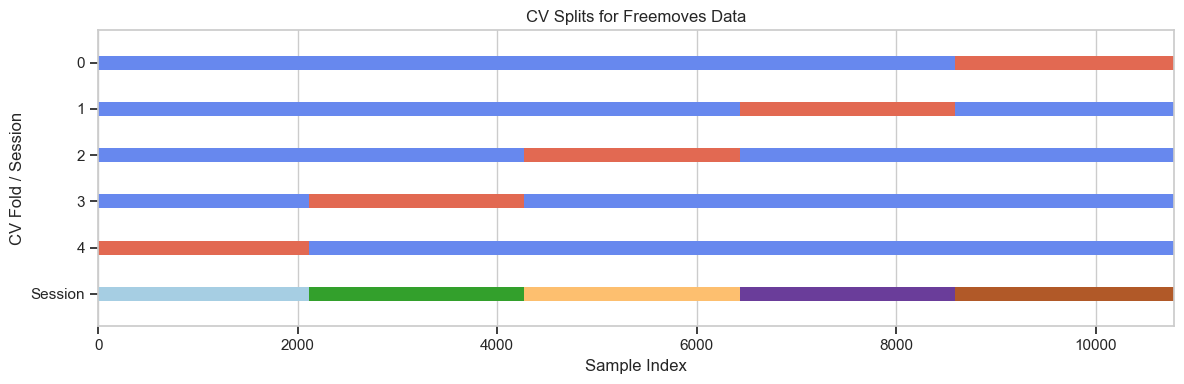

--- Evaluating Baseline Models (Freemoves) ---
CV Ridge_fm: 13.71 seconds
CV Lasso_fm: 41.43 seconds
CV RandomForest_fm: 44.04 seconds

--- Freemoves Baseline CV Performance Summary ---

Ridge_fm: RMSE: 10.7821±1.1785, NMSE: 0.8813±0.1188, R2: 0.0952±0.1060, FitTime: 4.61s

Lasso_fm: RMSE: 10.7318±1.1624, NMSE: 0.8874±0.0890, R2: 0.0890±0.0696, FitTime: 14.73s

RandomForest_fm: RMSE: 10.5957±1.9738, NMSE: 0.8346±0.1476, R2: 0.1419±0.1268, FitTime: 19.42s

--- Freemoves Baseline Summary Table ---
          Model     Type  RMSE_mean  RMSE_std  NMSE_mean  NMSE_std  R2_mean  R2_std  FitTime
       Ridge_fm Baseline    10.7821    1.1785     0.8813    0.1188   0.0952  0.1060   4.6110
       Lasso_fm Baseline    10.7318    1.1624     0.8874    0.0890   0.0890  0.0696  14.7343
RandomForest_fm Baseline    10.5957    1.9738     0.8346    0.1476   0.1419  0.1268  19.4189


In [12]:


# %% [markdown]
# ## 7. Feature Extractor Instantiation & Use (Objective 4 Prep)

# %%
# This extractor instance is for freemoves data.
# The class EMGFeatureExtractor is defined in Section 3 and is generic.
canonical_feature_extractor_freemoves = EMGFeatureExtractor(fs=FS,verb=False)
with timer("Fitting/Transforming Freemoves Data (Canonical Extractor)"):
    X_features_freemoves = canonical_feature_extractor_freemoves.fit_transform(X_windowed_freemoves)

print(f"\nFreemoves Feature Matrix Shape: {X_features_freemoves.shape}")
n_expected_features_freemoves = N_ELECTRODES_FREEMOVES * len(canonical_feature_extractor_freemoves._actual_feat_ext)
assert X_features_freemoves.shape[1]==n_expected_features_freemoves, "Feature dim mismatch for Freemoves!"
feature_names_out_freemoves = canonical_feature_extractor_freemoves.get_feature_names_out()
print(f"Generated {len(feature_names_out_freemoves)} feature names for Freemoves.")

# This X_input_for_nn will be specific to freemoves
X_input_for_nn_freemoves = X_features_freemoves
n_input_features_nn_freemoves = X_input_for_nn_freemoves.shape[1]

# %% [markdown]
# ## 8. Cross-Validation Strategy (Objective 3)

# %%
N_SPLITS_CV_FREEMOVES = N_SESSIONS_TRAIN_VAL_FREEMOVES
cv_strategy_freemoves = GroupKFold(n_splits=N_SPLITS_CV_FREEMOVES)
print(f"Using GroupKFold, {N_SPLITS_CV_FREEMOVES} splits for Freemoves.")
fig,ax_freemoves=plt.subplots(1,1,figsize=(12,4))
plot_cv_indices(cv_strategy_freemoves, X_features_freemoves, y_windowed_freemoves, groups_freemoves, N_SPLITS_CV_FREEMOVES, ax_obj=ax_freemoves)
plt.title("CV Splits for Freemoves Data") # Add specific title
plt.tight_layout();plt.show()


# %% [markdown]
# ## 9. Baseline Models: Training & Evaluation (Objective 4)

# %%
baseline_models_freemoves = { # Can be same model types, will be trained on freemoves data
    "Ridge_fm": Ridge(alpha=RIDGE_ALPHA,random_state=SEED),
    "Lasso_fm": Lasso(alpha=LASSO_ALPHA,max_iter=LASSO_MAX_ITER,tol=LASSO_TOL,random_state=SEED),
    "RandomForest_fm": RandomForestRegressor(n_estimators=RF_N_ESTIMATORS,max_depth=RF_MAX_DEPTH,
                                             max_features=RF_MAX_FEATURES,random_state=SEED,n_jobs=-1)
}
all_cv_results_freemoves={}; oof_predictions_freemoves={}
print("--- Evaluating Baseline Models (Freemoves) ---")
for model_name,model_instance in baseline_models_freemoves.items():
    with timer(f"CV {model_name}"):
        # EMGFeatureExtractor used here will be fit on freemoves data within each fold by the pipeline
        pipeline_obj=Pipeline([('feat_ext',EMGFeatureExtractor(fs=FS)),
                               ('scale',StandardScaler()),
                               ('reg',clone(model_instance))])
        scores_val=cross_validate(pipeline_obj,X_windowed_freemoves,y_windowed_freemoves,groups=groups_freemoves,
                                  cv=cv_strategy_freemoves,scoring=scorers,n_jobs=-1,
                                  return_train_score=False,return_estimator=False,error_score='raise')
        all_cv_results_freemoves[model_name]=scores_val
        oof_preds_val=cross_val_predict(pipeline_obj,X_windowed_freemoves,y_windowed_freemoves,groups=groups_freemoves,
                                        cv=cv_strategy_freemoves,n_jobs=-1,method='predict')
        oof_predictions_freemoves[model_name]=oof_preds_val

results_summary_list_freemoves=[]
print("\n--- Freemoves Baseline CV Performance Summary ---")
for model_name,scores_val in all_cv_results_freemoves.items():
    if model_name in baseline_models_freemoves:
        mean_rmse_val=-np.mean(scores_val['test_rmse']);std_rmse_val=np.std(scores_val['test_rmse'])
        mean_nmse_val=-np.mean(scores_val['test_nmse']);std_nmse_val=np.std(scores_val['test_nmse'])
        mean_r2_val=np.mean(scores_val['test_r2']);std_r2_val=np.std(scores_val['test_r2'])
        fit_time_mean_val=np.mean(scores_val['fit_time'])
        print(f"\n{model_name}: RMSE: {mean_rmse_val:.4f}±{std_rmse_val:.4f}, NMSE: {mean_nmse_val:.4f}±{std_nmse_val:.4f}, R2: {mean_r2_val:.4f}±{std_r2_val:.4f}, FitTime: {fit_time_mean_val:.2f}s")
        results_summary_list_freemoves.append({'Model':model_name,'Type':'Baseline','RMSE_mean':mean_rmse_val,'RMSE_std':std_rmse_val,
                                               'NMSE_mean':mean_nmse_val,'NMSE_std':std_nmse_val,'R2_mean':mean_r2_val,'R2_std':std_r2_val,'FitTime':fit_time_mean_val})
results_df_freemoves=pd.DataFrame(results_summary_list_freemoves)
print("\n--- Freemoves Baseline Summary Table ---"); print(results_df_freemoves.to_string(index=False))




--- RF Feature Importances (Freemoves) ---
Training RF on full Freemoves for Importance: 3.85 seconds

Freemoves RF Feature Importances (Top 30):


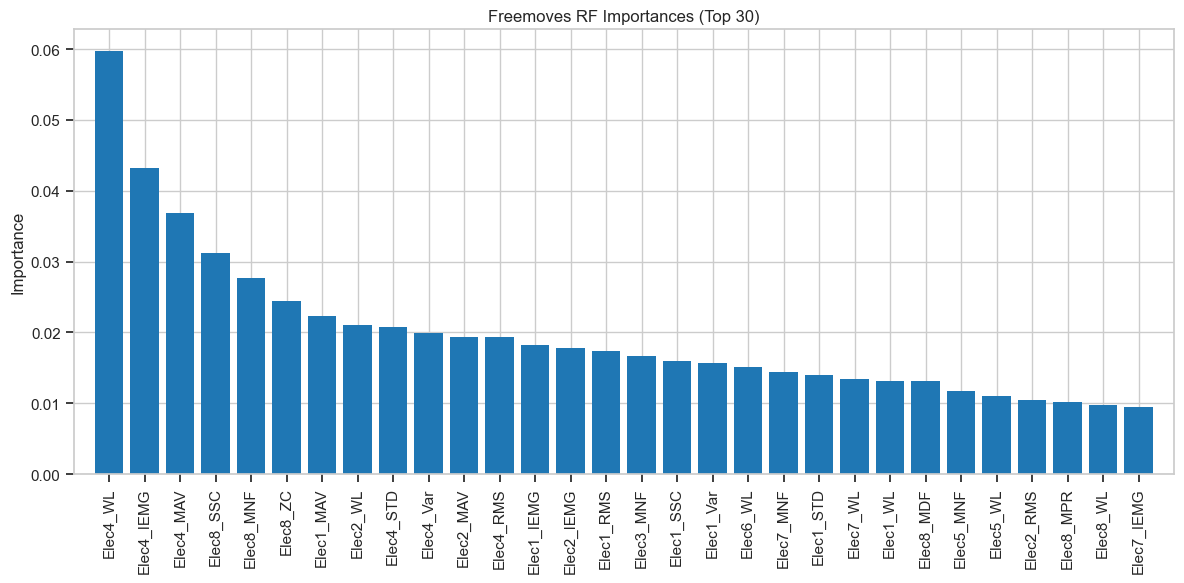


--- SFS (Freemoves) ---
SFS (Freemoves) failed: Passing extra keyword arguments to SequentialFeatureSelector.fit is only supported if enable_metadata_routing=True, which you can set using `sklearn.set_config`. See the User Guide <https://scikit-learn.org/stable/metadata_routing.html> for more details. Extra parameters passed are: {'groups'}. Skipping.
Fitting SFS for Freemoves: 0.00 seconds

Skipping SFS Freemoves eval (0 or all feats selected/SFS failed).

--- NN Mini-Grid Search (Freemoves) ---
Testing NN config for Freemoves: {'hidden': (128, 64, 32), 'dropout': 0.25}
  Config {'hidden': (128, 64, 32), 'dropout': 0.25} -> Val RMSE: 7.3018
Testing NN config for Freemoves: {'hidden': (256, 128, 64), 'dropout': 0.2}
  Config {'hidden': (256, 128, 64), 'dropout': 0.2} -> Val RMSE: 6.3297
Testing NN config for Freemoves: {'hidden': (512, 256, 128), 'dropout': 0.3}
  Config {'hidden': (512, 256, 128), 'dropout': 0.3} -> Val RMSE: 6.0353

Best NN Config (Freemoves grid): {'hidden': (512, 

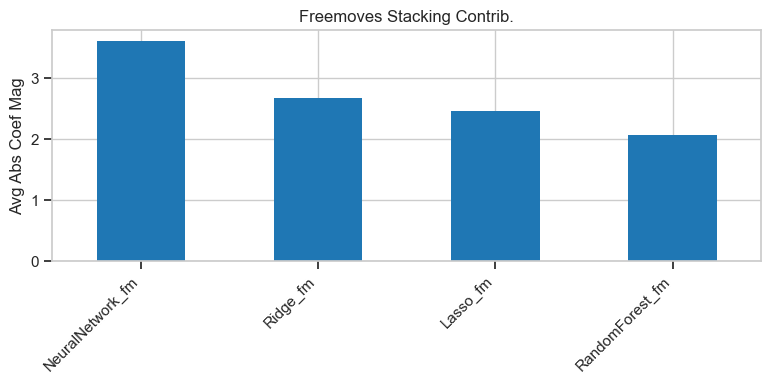

In [13]:
# %% [markdown]
# ## 10. Feature Importance & Selection (Objective 4)

# %%
print("\n--- RF Feature Importances (Freemoves) ---")
# Use X_input_for_nn_freemoves (derived from freemoves data)
temp_scaler_rf_freemoves=StandardScaler(); X_features_scaled_rf_freemoves=temp_scaler_rf_freemoves.fit_transform(X_input_for_nn_freemoves)
rf_for_importance_freemoves=clone(baseline_models_freemoves["RandomForest_fm"]) # Use the freemoves RF
with timer("Training RF on full Freemoves for Importance"):
    rf_for_importance_freemoves.fit(X_features_scaled_rf_freemoves,y_windowed_freemoves)
importances_freemoves=rf_for_importance_freemoves.feature_importances_
indices_freemoves=np.argsort(importances_freemoves)[::-1]
# feature_names_out_freemoves was generated in Section 7
print("\nFreemoves RF Feature Importances (Top 30):")
n_top_features_plot_val=30; plt.figure(figsize=(12,6)); plt.title(f"Freemoves RF Importances (Top {n_top_features_plot_val})")
plt.bar(range(n_top_features_plot_val),importances_freemoves[indices_freemoves[:n_top_features_plot_val]],align='center')
plt.xticks(range(n_top_features_plot_val),[feature_names_out_freemoves[i] for i in indices_freemoves[:n_top_features_plot_val]],rotation=90)
plt.xlim([-1,n_top_features_plot_val]);plt.ylabel("Importance");plt.tight_layout();plt.show()

print("\n--- SFS (Freemoves) ---")
sfs_estimator_freemoves=Ridge(alpha=RIDGE_ALPHA,random_state=SEED)
sfs_freemoves=SequentialFeatureSelector(estimator=sfs_estimator_freemoves,n_features_to_select=SFS_N_FEATURES,tol=SFS_TOL,
                                        direction=SFS_DIRECTION,scoring=scorers['rmse'],cv=cv_strategy_freemoves,n_jobs=-1)
# *** CORRECTED LINE BELOW ***
temp_scaler_sfs_freemoves=StandardScaler();X_features_scaled_sfs_freemoves=temp_scaler_sfs_freemoves.fit_transform(X_input_for_nn_freemoves)
selected_feature_names_sfs_freemoves=[]; selected_feature_types_sfs_freemoves=[]
n_selected_features_sfs_freemoves = 0 # Initialize
with timer("Fitting SFS for Freemoves"):
    try:
        sfs_freemoves.fit(X_features_scaled_sfs_freemoves,y_windowed_freemoves,groups=groups_freemoves)
        selected_feature_indices_sfs_freemoves=sfs_freemoves.get_support(indices=True)
        selected_feature_names_sfs_freemoves=[feature_names_out_freemoves[i] for i in selected_feature_indices_sfs_freemoves]
        n_selected_features_sfs_freemoves=len(selected_feature_names_sfs_freemoves)
        print(f"\nSFS (Freemoves) selected {n_selected_features_sfs_freemoves} features.")
        print(f"Selected (first 50): {selected_feature_names_sfs_freemoves[:50]}{'...' if n_selected_features_sfs_freemoves>50 else ''}")
        if n_selected_features_sfs_freemoves > 0:
            selected_feature_types_sfs_freemoves=sorted(list(set(f.split('_',1)[1] for f in selected_feature_names_sfs_freemoves)))
    except Exception as e:print(f"SFS (Freemoves) failed: {e}. Skipping."); n_selected_features_sfs_freemoves=0

if n_selected_features_sfs_freemoves > 0 and n_selected_features_sfs_freemoves < len(feature_names_out_freemoves):
    print("\n--- Eval Best Freemoves Baseline with SFS Feats ---")
    best_baseline_name_freemoves=results_df_freemoves.loc[results_df_freemoves['RMSE_mean'].idxmin()]['Model']
    print(f"Best freemoves baseline for SFS eval: {best_baseline_name_freemoves}.")
    best_model_instance_sfs_freemoves=clone(baseline_models_freemoves[best_baseline_name_freemoves]) # Get from freemoves dict
    print(f"Using {len(selected_feature_types_sfs_freemoves)} SFS feature types for Freemoves: {selected_feature_types_sfs_freemoves}")
    sfs_pipeline_freemoves=Pipeline([('feat_ext',EMGFeatureExtractor(sel_feat=selected_feature_types_sfs_freemoves,fs=FS)),
                                     ('scale',StandardScaler()),('reg',best_model_instance_sfs_freemoves)])
    with timer(f"CV {best_baseline_name_freemoves} with SFS (Freemoves)"):
        sfs_scores_val=cross_validate(sfs_pipeline_freemoves,X_windowed_freemoves,y_windowed_freemoves,groups=groups_freemoves,
                                      cv=cv_strategy_freemoves,scoring=scorers,n_jobs=-1,return_train_score=False)
        model_name_sfs_val=f"{best_baseline_name_freemoves}_SFS"
        all_cv_results_freemoves[model_name_sfs_val]=sfs_scores_val
        mean_rmse_val=-np.mean(sfs_scores_val['test_rmse']);std_rmse_val=np.std(sfs_scores_val['test_rmse'])
        mean_nmse_val=-np.mean(sfs_scores_val['test_nmse']);std_nmse_val=np.std(sfs_scores_val['test_nmse'])
        mean_r2_val=np.mean(sfs_scores_val['test_r2']);std_r2_val=np.std(sfs_scores_val['test_r2']);fit_time_mean_val=np.mean(sfs_scores_val['fit_time'])
        print(f"\n{model_name_sfs_val}: RMSE: {mean_rmse_val:.4f}±{std_rmse_val:.4f}, R2: {mean_r2_val:.4f}±{std_r2_val:.4f}")
        results_summary_list_freemoves.append({'Model':model_name_sfs_val,'Type':'Baseline_SFS','RMSE_mean':mean_rmse_val,'RMSE_std':std_rmse_val,
                                               'NMSE_mean':mean_nmse_val,'NMSE_std':std_nmse_val,'R2_mean':mean_r2_val,'R2_std':std_r2_val,'FitTime':fit_time_mean_val})
        results_df_freemoves=pd.DataFrame(results_summary_list_freemoves)
else:print("\nSkipping SFS Freemoves eval (0 or all feats selected/SFS failed).")
# %% [markdown]
# ## 11. Sophisticated Model: Neural Network (Objective 5)

# %%
print("\n--- NN Mini-Grid Search (Freemoves) ---")
nn_grid_search_configs=[{"hidden":(128,64,32),"dropout":0.25}, {"hidden":(256,128,64),"dropout":0.2}, {"hidden":(512,256,128),"dropout":0.3}]
best_nn_config_freemoves=None; best_nn_val_rmse_freemoves=float('inf')
try:
    X_train_grid_fm,X_val_grid_fm,y_train_grid_fm,y_val_grid_fm,_,_=train_test_split(
        X_input_for_nn_freemoves,y_windowed_freemoves,groups_freemoves,test_size=0.2,random_state=SEED,stratify=groups_freemoves)
except ValueError:
    print("Stratify failed for Freemoves grid search, using random split.");X_train_grid_fm,X_val_grid_fm,y_train_grid_fm,y_val_grid_fm=train_test_split(X_input_for_nn_freemoves,y_windowed_freemoves,test_size=0.2,random_state=SEED)
scaler_grid_fm=StandardScaler();X_train_grid_scaled_fm=scaler_grid_fm.fit_transform(X_train_grid_fm);X_val_grid_scaled_fm=scaler_grid_fm.transform(X_val_grid_fm)
ds_train_grid_fm=TensorDataset(torch.tensor(X_train_grid_scaled_fm).float(),torch.tensor(y_train_grid_fm).float())
ds_val_grid_fm=TensorDataset(torch.tensor(X_val_grid_scaled_fm).float(),torch.tensor(y_val_grid_fm).float())
loader_train_grid_fm=DataLoader(ds_train_grid_fm,batch_size=NN_BATCH_SIZE,shuffle=True,num_workers=2,pin_memory=False)
loader_val_grid_fm=DataLoader(ds_val_grid_fm,batch_size=NN_BATCH_SIZE*2,shuffle=False,num_workers=2,pin_memory=False)

for config_item_val in nn_grid_search_configs:
    print(f"Testing NN config for Freemoves: {config_item_val}")
    current_config_dict={'hidden':config_item_val['hidden'],'dropout':config_item_val['dropout'],'lr':NN_LR,'weight_decay':NN_WEIGHT_DECAY,
                         'batch_size':NN_BATCH_SIZE,'max_epochs':NN_MAX_EPOCHS,'patience_lr':NN_PATIENCE_LR,'patience_es':NN_PATIENCE_ES}
    nn_model_grid = EMG_NN(n_input_features_nn_freemoves, N_JOINTS_FREEMOVES, # Use freemoves specific counts
                           hidden_config=config_item_val['hidden'], dropout_prob=config_item_val['dropout']).to(device)
    criterion_grid_obj=nn.MSELoss(); optimizer_grid_obj=optim.Adam(nn_model_grid.parameters(),lr=NN_LR,weight_decay=NN_WEIGHT_DECAY)
    scheduler_grid_obj=optim.lr_scheduler.ReduceLROnPlateau(optimizer_grid_obj,patience=NN_PATIENCE_LR,factor=0.5,verbose=False)
    early_stopper_grid_obj=EarlyStop(patience=NN_PATIENCE_ES)
    for epoch_grid_idx in range(NN_MAX_EPOCHS):
        train_nn_epoch(nn_model_grid,loader_train_grid_fm,criterion_grid_obj,optimizer_grid_obj,device)
        mse_val_grid,_,_=evaluate_nn_model(nn_model_grid,loader_val_grid_fm,criterion_grid_obj,device)
        scheduler_grid_obj.step(mse_val_grid);
        if early_stopper_grid_obj(mse_val_grid):break
    rmse_val_grid_val=np.sqrt(early_stopper_grid_obj.best_score);print(f"  Config {config_item_val} -> Val RMSE: {rmse_val_grid_val:.4f}")
    if rmse_val_grid_val<best_nn_val_rmse_freemoves:best_nn_val_rmse_freemoves=rmse_val_grid_val;best_nn_config_freemoves=current_config_dict
print(f"\nBest NN Config (Freemoves grid): {best_nn_config_freemoves} (Val RMSE: {best_nn_val_rmse_freemoves:.4f})")
if best_nn_config_freemoves is None:
    print("Grid fail for Freemoves, using default.");best_nn_config_freemoves={'hidden':(256,128,64),'dropout':0.2,'lr':NN_LR,'weight_decay':NN_WEIGHT_DECAY,
                                                                              'batch_size':NN_BATCH_SIZE,'max_epochs':NN_MAX_EPOCHS,'patience_lr':NN_PATIENCE_LR,'patience_es':NN_PATIENCE_ES}
NN_MODEL_NAME_FREEMOVES="NeuralNetwork_fm" # Unique name for freemoves NN results
print(f"\n--- CV {NN_MODEL_NAME_FREEMOVES} (Freemoves) ---")
with timer(f"CV & OOF for {NN_MODEL_NAME_FREEMOVES}"):
    nn_oof_preds_freemoves,nn_cv_scores_freemoves=perform_nn_cv_oof(X_input_for_nn_freemoves,y_windowed_freemoves,groups_freemoves,
                                                                    cv_strategy_freemoves,best_nn_config_freemoves,device)
all_cv_results_freemoves[NN_MODEL_NAME_FREEMOVES]=nn_cv_scores_freemoves
oof_predictions_freemoves[NN_MODEL_NAME_FREEMOVES]=nn_oof_preds_freemoves # Store freemoves OOF
mean_rmse_val=-np.mean(nn_cv_scores_freemoves['test_rmse']);std_rmse_val=np.std(nn_cv_scores_freemoves['test_rmse'])
mean_nmse_val=-np.mean(nn_cv_scores_freemoves['test_nmse']);std_nmse_val=np.std(nn_cv_scores_freemoves['test_nmse'])
mean_r2_val=np.mean(nn_cv_scores_freemoves['test_r2']);std_r2_val=np.std(nn_cv_scores_freemoves['test_r2'])
fit_time_mean_val=np.mean(nn_cv_scores_freemoves['fit_time'])
print(f"\n{NN_MODEL_NAME_FREEMOVES} CV (Freemoves): RMSE: {mean_rmse_val:.4f}±{std_rmse_val:.4f}, NMSE: {mean_nmse_val:.4f}±{std_nmse_val:.4f}, R2: {mean_r2_val:.4f}±{std_r2_val:.4f}, AvgFoldFitTime: {fit_time_mean_val:.2f}s")
results_summary_list_freemoves.append({'Model':NN_MODEL_NAME_FREEMOVES,'Type':'Sophisticated','RMSE_mean':mean_rmse_val,'RMSE_std':std_rmse_val,
                                       'NMSE_mean':mean_nmse_val,'NMSE_std':std_nmse_val,'R2_mean':mean_r2_val,'R2_std':std_r2_val,'FitTime':fit_time_mean_val*N_SPLITS_CV_FREEMOVES})
results_df_freemoves=pd.DataFrame(results_summary_list_freemoves)

# %% [markdown]
# ## 12. Ensembling Strategies (Objective 6)

# %%
print("\n--- Averaging Ensemble (Freemoves) ---")
# oof_predictions_freemoves now holds all OOFs for freemoves models
model_names_for_avg_freemoves=list(oof_predictions_freemoves.keys());print(f"Averaging from (Freemoves): {model_names_for_avg_freemoves}")
oof_preds_sum_freemoves=np.zeros_like(y_windowed_freemoves,dtype=np.float64);valid_preds_count_freemoves=0
for model_name_val in model_names_for_avg_freemoves:
    preds_val=oof_predictions_freemoves.get(model_name_val)
    if preds_val is not None and preds_val.shape==y_windowed_freemoves.shape:oof_preds_sum_freemoves+=preds_val;valid_preds_count_freemoves+=1
    else:print(f"  Warn: Skipping {model_name_val} from Freemoves averaging.")
if valid_preds_count_freemoves>0:
    oof_preds_avg_freemoves=oof_preds_sum_freemoves/valid_preds_count_freemoves
    avg_rmse_freemoves=root_mean_squared_error(y_windowed_freemoves,oof_preds_avg_freemoves)
    avg_nmse_freemoves=normalized_mean_squared_error(y_windowed_freemoves,oof_preds_avg_freemoves)
    avg_r2_freemoves=r2_score(y_windowed_freemoves,oof_preds_avg_freemoves)
    print(f"\nAvg Ens Perf (Freemoves OOF): RMSE: {avg_rmse_freemoves:.4f}, NMSE: {avg_nmse_freemoves:.4f}, R2: {avg_r2_freemoves:.4f}")
    results_summary_list_freemoves.append({'Model':'AverageEnsemble_fm','Type':'Ensemble','RMSE_mean':avg_rmse_freemoves,'RMSE_std':np.nan,
                                           'NMSE_mean':avg_nmse_freemoves,'NMSE_std':np.nan,'R2_mean':avg_r2_freemoves,'R2_std':np.nan,'FitTime':np.nan})
    results_df_freemoves=pd.DataFrame(results_summary_list_freemoves)
else:print("Could not eval Freemoves Avg Ens.")

print("\n--- Stacking Ensemble (Freemoves) ---")
model_names_for_stacking_freemoves=list(oof_predictions_freemoves.keys());print(f"Stacking from (Freemoves): {model_names_for_stacking_freemoves}")
X_meta_list_freemoves=[]; valid_stacking_model_names_freemoves=[]
for model_name_val in model_names_for_stacking_freemoves:
    preds_val=oof_predictions_freemoves.get(model_name_val)
    if preds_val is not None and preds_val.shape==y_windowed_freemoves.shape:X_meta_list_freemoves.append(preds_val);valid_stacking_model_names_freemoves.append(model_name_val)
    else:print(f"  Warn: Skipping {model_name_val} from Freemoves stacking.")
if not X_meta_list_freemoves:print("Could not stack Freemoves.");X_meta_freemoves=None
else:
    try:X_meta_freemoves=np.hstack(X_meta_list_freemoves);print(f"Freemoves Meta-Features Shape: {X_meta_freemoves.shape}")
    except Exception as e:print(f"Error creating Freemoves X_meta: {e}.");X_meta_freemoves=None
if X_meta_freemoves is not None:
    meta_learners_freemoves={"Stacking_Ridge_fm":Ridge(alpha=META_RIDGE_ALPHA,random_state=SEED),
                             "Stacking_RF_fm":RandomForestRegressor(n_estimators=META_RF_N_ESTIMATORS,max_depth=META_RF_MAX_DEPTH,random_state=SEED,n_jobs=-1)}
    for meta_name_val,meta_model_val in meta_learners_freemoves.items():
        print(f"\n--- CV Meta-Learner: {meta_name_val} (Freemoves) ---")
        with timer(f"CV {meta_name_val}"):
            stacking_scores_val=cross_validate(clone(meta_model_val),X_meta_freemoves,y_windowed_freemoves,groups=groups_freemoves,
                                               cv=cv_strategy_freemoves,scoring=scorers,n_jobs=-1,return_train_score=False,error_score='raise')
            all_cv_results_freemoves[meta_name_val]=stacking_scores_val
            mean_rmse_val=-np.mean(stacking_scores_val['test_rmse']);std_rmse_val=np.std(stacking_scores_val['test_rmse'])
            mean_nmse_val=-np.mean(stacking_scores_val['test_nmse']);std_nmse_val=np.std(stacking_scores_val['test_nmse'])
            mean_r2_val=np.mean(stacking_scores_val['test_r2']);std_r2_val=np.std(stacking_scores_val['test_r2']);fit_time_mean_val=np.mean(stacking_scores_val['fit_time'])
            print(f"\n{meta_name_val} CV Perf: RMSE: {mean_rmse_val:.4f}±{std_rmse_val:.4f}, R2: {mean_r2_val:.4f}±{std_r2_val:.4f}")
            results_summary_list_freemoves.append({'Model':meta_name_val,'Type':'Ensemble','RMSE_mean':mean_rmse_val,'RMSE_std':std_rmse_val,
                                                   'NMSE_mean':mean_nmse_val,'NMSE_std':std_nmse_val,'R2_mean':mean_r2_val,'R2_std':std_r2_val,'FitTime':fit_time_mean_val*N_SPLITS_CV_FREEMOVES})
    results_df_freemoves=pd.DataFrame(results_summary_list_freemoves)
    print("\n--- Stacking Contribution Analysis (Freemoves - Ridge Meta) ---")
    final_meta_ridge_freemoves=Ridge(alpha=META_RIDGE_ALPHA);final_meta_ridge_freemoves.fit(X_meta_freemoves,y_windowed_freemoves)
    if hasattr(final_meta_ridge_freemoves,'coef_'):
        coeffs_val=final_meta_ridge_freemoves.coef_;avg_coeffs_mag_dict={};n_joints_meta_val=y_windowed_freemoves.shape[1]
        print("Avg. Abs. Coef Mag per Base Model (Freemoves):")
        for i_val,model_name_val in enumerate(valid_stacking_model_names_freemoves):
            model_coeffs_val=coeffs_val[:,i_val*n_joints_meta_val:(i_val+1)*n_joints_meta_val];avg_mag_val=np.mean(np.abs(model_coeffs_val))
            avg_coeffs_mag_dict[model_name_val]=avg_mag_val;print(f"  {model_name_val}: {avg_mag_val:.4f}")
        coeffs_mag_series_val=pd.Series(avg_coeffs_mag_dict).sort_values(ascending=False)
        plt.figure(figsize=(8,4));coeffs_mag_series_val.plot(kind='bar');plt.title('Freemoves Stacking Contrib.')
        plt.ylabel('Avg Abs Coef Mag');plt.xticks(rotation=45,ha='right');plt.tight_layout();plt.show()
    else:print("Could not analyze coeffs for Freemoves Stacking_Ridge_fm.")

In [14]:


# %% [markdown]
# ## 13. Final Model Selection & Training (Objective 7 Prep - Freemoves)

# %%
print("\n"+"="*60+"\n       Final Model Selection for Freemoves Gestures\n"+"="*60)
results_df_freemoves=pd.DataFrame(results_summary_list_freemoves).sort_values(by='RMSE_mean').reset_index(drop=True)
print("\n--- Final Freemoves Model Comparison Table ---");print(results_df_freemoves.to_string(index=False))
try:
    best_row_freemoves=results_df_freemoves.iloc[0];best_overall_model_name_freemoves=best_row_freemoves['Model']
    best_overall_rmse_freemoves=best_row_freemoves['RMSE_mean']
    print(f"\nSelected Best Freemoves Model: '{best_overall_model_name_freemoves}' (CV RMSE: {best_overall_rmse_freemoves:.4f})")
except Exception as e:raise RuntimeError(f"Could not determine best freemoves model: {e}")

final_model_for_prediction_freemoves=None # Initialize
# Use a unique filename for the freemoves model
final_model_save_path_freemoves=MODEL_SAVE_DIR/f"final_model_{best_overall_model_name_freemoves.lower().replace(' ','_')}.pkl"
print(f"\n--- Preparing final '{best_overall_model_name_freemoves}' on all Freemoves training data ---")

if best_overall_model_name_freemoves==NN_MODEL_NAME_FREEMOVES: # Check against freemoves NN name
    with timer(f"Training final {NN_MODEL_NAME_FREEMOVES} (Freemoves)"):
        scaler_final_nn_fm=StandardScaler();X_nn_scaled_final_fm=scaler_final_nn_fm.fit_transform(X_input_for_nn_freemoves)
        ds_final_nn_fm=TensorDataset(torch.tensor(X_nn_scaled_final_fm).float(),torch.tensor(y_windowed_freemoves).float())
        loader_final_nn_fm=DataLoader(ds_final_nn_fm,batch_size=best_nn_config_freemoves['batch_size'],shuffle=True,num_workers=2,pin_memory=False)
        model_final_nn_fm = EMG_NN(n_input_features_nn_freemoves, N_JOINTS_FREEMOVES,
                                   hidden_config=best_nn_config_freemoves['hidden'], dropout_prob=best_nn_config_freemoves['dropout']).to(device)
        criterion_final_nn_fm=nn.MSELoss();optimizer_final_nn_fm=optim.Adam(model_final_nn_fm.parameters(),lr=best_nn_config_freemoves['lr'],weight_decay=best_nn_config_freemoves['weight_decay'])
        for epoch_idx_val in range(best_nn_config_freemoves['max_epochs']):
            train_loss_val=train_nn_epoch(model_final_nn_fm,loader_final_nn_fm,criterion_final_nn_fm,optimizer_final_nn_fm,device)
            if (epoch_idx_val+1)%20==0 or epoch_idx_val==best_nn_config_freemoves['max_epochs']-1:print(f"  Final NN Epoch {epoch_idx_val+1}, Loss: {train_loss_val:.6f}")
        final_model_for_prediction_freemoves={'model_type':"NeuralNetwork",'model':model_final_nn_fm.cpu(),'scaler':scaler_final_nn_fm,
                                              'feature_extractor':canonical_feature_extractor_freemoves} # Use freemoves extractor
        torch.save(model_final_nn_fm.state_dict(),MODEL_SAVE_DIR/f"final_{NN_MODEL_NAME_FREEMOVES.lower()}_state.pth")
        with open(MODEL_SAVE_DIR/f"final_{NN_MODEL_NAME_FREEMOVES.lower()}_scaler.pkl",'wb') as f_val:pickle.dump(scaler_final_nn_fm,f_val)
        print(f"Final {NN_MODEL_NAME_FREEMOVES} (Freemoves) trained & saved.")

elif best_overall_model_name_freemoves.startswith('AverageEnsemble'): # e.g. AverageEnsemble_fm
    print("Prep final AvgEns (Freemoves)...");trained_base_models_avg_fm={}
    # model_names_for_avg_freemoves was defined in Section 12 for freemoves
    for model_name_val in model_names_for_avg_freemoves:
        if model_name_val==NN_MODEL_NAME_FREEMOVES: # Check if NN is a base
             # This assumes if NN is part of ensemble, it was already trained as 'final_model_for_prediction_freemoves' if it was the best
            if 'final_model_for_prediction_freemoves' in locals() and final_model_for_prediction_freemoves and \
               final_model_for_prediction_freemoves['model_type']=="NeuralNetwork" and \
               final_model_for_prediction_freemoves.get('name', NN_MODEL_NAME_FREEMOVES) == NN_MODEL_NAME_FREEMOVES : # Check name if NN models have names
                trained_base_models_avg_fm[NN_MODEL_NAME_FREEMOVES]=final_model_for_prediction_freemoves
                print(f"  Reusing trained final {NN_MODEL_NAME_FREEMOVES} for AvgEns.")
            else: # Need to train the NN specifically for the ensemble if it wasn't the absolute best
                print(f"  Training final {NN_MODEL_NAME_FREEMOVES} as base for AvgEns (Freemoves)...")
                # Simplified NN training for ensemble base (can be expanded if needed)
                sfn_base=StandardScaler();Xn_s_f_base=sfn_base.fit_transform(X_input_for_nn_freemoves)
                ds_fn_base=TensorDataset(torch.tensor(Xn_s_f_base).float(),torch.tensor(y_windowed_freemoves).float())
                ld_fn_base=DataLoader(ds_fn_base,batch_size=best_nn_config_freemoves['batch_size'],shuffle=True)
                mfn_base = EMG_NN(n_input_features_nn_freemoves,N_JOINTS_FREEMOVES,hidden_config=best_nn_config_freemoves['hidden'],dropout_prob=best_nn_config_freemoves['dropout']).to(device)
                crit_fn_base=nn.MSELoss();opt_fn_base=optim.Adam(mfn_base.parameters(),lr=best_nn_config_freemoves['lr'],weight_decay=best_nn_config_freemoves['weight_decay'])
                for ep_base in range(best_nn_config_freemoves['max_epochs']): train_nn_epoch(mfn_base,ld_fn_base,crit_fn_base,opt_fn_base,device)
                trained_base_models_avg_fm[NN_MODEL_NAME_FREEMOVES]={'model_type':"NeuralNetwork",'model':mfn_base.cpu(),'scaler':sfn_base,'feature_extractor':canonical_feature_extractor_freemoves}
        elif model_name_val in baseline_models_freemoves: # Check against freemoves baseline dict keys
            pipeline_obj=Pipeline([('feat_ext',EMGFeatureExtractor(fs=FS)),('scale',StandardScaler()),('reg',clone(baseline_models_freemoves[model_name_val]))])
            with timer(f"  Fit final base {model_name_val}"):pipeline_obj.fit(X_windowed_freemoves,y_windowed_freemoves);trained_base_models_avg_fm[model_name_val]=pipeline_obj
    final_model_for_prediction_freemoves={'model_type':'AverageEnsemble','base_models_trained':trained_base_models_avg_fm,
                                          'base_model_order':model_names_for_avg_freemoves} # Save order
    with open(final_model_save_path_freemoves,'wb') as f_val:pickle.dump(final_model_for_prediction_freemoves,f_val);print(f"Final AvgEns (Freemoves) saved to {final_model_save_path_freemoves}")

elif best_overall_model_name_freemoves.startswith('Stacking_'): # e.g. Stacking_Ridge_fm
    print(f"Prep final StackEns: {best_overall_model_name_freemoves} (Freemoves)...");trained_base_models_stack_fm={};
    meta_learner_key_fm=best_overall_model_name_freemoves # This is the key for meta_learners_freemoves
    base_meta_learner_fm = meta_learners_freemoves.get(meta_learner_key_fm) # Get from freemoves meta_learners
    if base_meta_learner_fm is None: raise ValueError(f"Meta-learner {meta_learner_key_fm} not found for Freemoves.")
    # valid_stacking_model_names_freemoves was defined in Section 12
    for model_name_val in valid_stacking_model_names_freemoves:
        if model_name_val==NN_MODEL_NAME_FREEMOVES:
            if 'final_model_for_prediction_freemoves' in locals() and final_model_for_prediction_freemoves and \
               final_model_for_prediction_freemoves['model_type']=="NeuralNetwork" and \
               final_model_for_prediction_freemoves.get('name', NN_MODEL_NAME_FREEMOVES) == NN_MODEL_NAME_FREEMOVES:
                trained_base_models_stack_fm[NN_MODEL_NAME_FREEMOVES]=final_model_for_prediction_freemoves
                print(f"  Reusing trained final {NN_MODEL_NAME_FREEMOVES} for StackEns.")
            else: # Train NN base for stacking
                print(f"  Training final {NN_MODEL_NAME_FREEMOVES} as base for StackEns (Freemoves)...")
                sfn_base_st=StandardScaler();Xn_s_f_base_st=sfn_base_st.fit_transform(X_input_for_nn_freemoves)
                ds_fn_base_st=TensorDataset(torch.tensor(Xn_s_f_base_st).float(),torch.tensor(y_windowed_freemoves).float())
                ld_fn_base_st=DataLoader(ds_fn_base_st,batch_size=best_nn_config_freemoves['batch_size'],shuffle=True)
                mfn_base_st = EMG_NN(n_input_features_nn_freemoves,N_JOINTS_FREEMOVES,hidden_config=best_nn_config_freemoves['hidden'],dropout_prob=best_nn_config_freemoves['dropout']).to(device)
                crit_fn_base_st=nn.MSELoss();opt_fn_base_st=optim.Adam(mfn_base_st.parameters(),lr=best_nn_config_freemoves['lr'],weight_decay=best_nn_config_freemoves['weight_decay'])
                for ep_base_st in range(best_nn_config_freemoves['max_epochs']): train_nn_epoch(mfn_base_st,ld_fn_base_st,crit_fn_base_st,opt_fn_base_st,device)
                trained_base_models_stack_fm[NN_MODEL_NAME_FREEMOVES]={'model_type':"NeuralNetwork",'model':mfn_base_st.cpu(),'scaler':sfn_base_st,'feature_extractor':canonical_feature_extractor_freemoves}
        elif model_name_val in baseline_models_freemoves:
            pipeline_obj=Pipeline([('feat_ext',EMGFeatureExtractor(fs=FS)),('scale',StandardScaler()),('reg',clone(baseline_models_freemoves[model_name_val]))])
            with timer(f"  Fit final base {model_name_val}"):pipeline_obj.fit(X_windowed_freemoves,y_windowed_freemoves);trained_base_models_stack_fm[model_name_val]=pipeline_obj
    final_meta_learner_fm=clone(base_meta_learner_fm)
    if X_meta_freemoves is None:raise ValueError("X_meta_freemoves not available for final meta train.")
    with timer(f"  Fit final meta {meta_learner_key_fm}"):final_meta_learner_fm.fit(X_meta_freemoves,y_windowed_freemoves)
    final_model_for_prediction_freemoves={'model_type':'StackingEnsemble','name':meta_learner_key_fm,'meta_model':final_meta_learner_fm,
                                          'base_models_trained':trained_base_models_stack_fm,'base_model_order':valid_stacking_model_names_freemoves}
    with open(final_model_save_path_freemoves,'wb') as f_val:pickle.dump(final_model_for_prediction_freemoves,f_val);print(f"Final StackEns {meta_learner_key_fm} (Freemoves) saved to {final_model_save_path_freemoves}")

elif best_overall_model_name_freemoves.endswith("_SFS"): # e.g. Ridge_fm_SFS
    sfs_base_model_key = best_overall_model_name_freemoves.replace("_SFS", "") # Ridge_fm
    if sfs_base_model_key not in baseline_models_freemoves:
        raise ValueError(f"Base model {sfs_base_model_key} for SFS not in freemoves baselines.")
    print(f"Retrain final SFS: {best_overall_model_name_freemoves} (Freemoves)...")
    sfs_regressor_final_fm=clone(baseline_models_freemoves[sfs_base_model_key])
    # selected_feature_types_sfs_freemoves was defined in Section 10 for freemoves
    if not selected_feature_types_sfs_freemoves:raise ValueError("SFS feats not found for freemoves SFS model.")
    final_model_for_prediction_freemoves=Pipeline([('feat_ext',EMGFeatureExtractor(sel_feat=selected_feature_types_sfs_freemoves,fs=FS)),
                                                   ('scale',StandardScaler()),('reg',sfs_regressor_final_fm)])
    with timer(f"Fit final SFS {best_overall_model_name_freemoves}"):final_model_for_prediction_freemoves.fit(X_windowed_freemoves,y_windowed_freemoves)
    with open(final_model_save_path_freemoves,'wb') as f_val:pickle.dump(final_model_for_prediction_freemoves,f_val);print(f"Final SFS {best_overall_model_name_freemoves} (Freemoves) saved to {final_model_save_path_freemoves}")

elif best_overall_model_name_freemoves in baseline_models_freemoves: # e.g. Ridge_fm
    print(f"Retrain final baseline: {best_overall_model_name_freemoves} (Freemoves)...")
    final_baseline_regressor_fm=clone(baseline_models_freemoves[best_overall_model_name_freemoves])
    final_model_for_prediction_freemoves=Pipeline([('feat_ext',EMGFeatureExtractor(fs=FS)),('scale',StandardScaler()),('reg',final_baseline_regressor_fm)])
    with timer(f"Fit final baseline {best_overall_model_name_freemoves}"):final_model_for_prediction_freemoves.fit(X_windowed_freemoves,y_windowed_freemoves)
    with open(final_model_save_path_freemoves,'wb') as f_val:pickle.dump(final_model_for_prediction_freemoves,f_val);print(f"Final baseline {best_overall_model_name_freemoves} (Freemoves) saved to {final_model_save_path_freemoves}")
else:raise ValueError(f"Don't know how to retrain '{best_overall_model_name_freemoves}' for freemoves.")
if final_model_for_prediction_freemoves is None:raise RuntimeError("Failed to prep final model for freemoves.")
print(f"\n'{best_overall_model_name_freemoves}' fully prepared for FREEMOVES prediction.")

# %% [markdown]
# ## 14. Test Set Prediction (Objective 7 Implementation - Freemoves)

# %%
print("\n"+"="*60+"\n       Generating Predictions for Freemoves Test Set\n"+"="*60)
print("\n--- Loading & Preprocessing Freemoves Test Data ---")
X_test_raw_fm_data=np.load(X_TEST_PATH_FREEMOVES);print(f"Raw freemoves test shape: {X_test_raw_fm_data.shape}")
n_test_sess_fm=X_test_raw_fm_data.shape[0];n_test_wins_sess_fm=X_test_raw_fm_data.shape[1]
n_test_timepoints_fm=X_test_raw_fm_data.shape[3] # Time is last dim in testset_X
# Reshape: (total_test_windows, n_electrodes, n_timepoints_per_window)
X_test_reshaped_fm=X_test_raw_fm_data.reshape(-1,N_ELECTRODES_FREEMOVES,n_test_timepoints_fm)
print(f"Reshaped freemoves test data: {X_test_reshaped_fm.shape}")
X_test_to_predict_fm=X_test_reshaped_fm
if APPLY_FILTERING:
    with timer("Filtering Freemoves Test Data"):
        X_test_filtered_fm=np.zeros_like(X_test_reshaped_fm)
        for i_win_idx in range(X_test_reshaped_fm.shape[0]):
            # Remove DC offset
            dc_removed_val=X_test_reshaped_fm[i_win_idx]-np.mean(X_test_reshaped_fm[i_win_idx],axis=-1,keepdims=True)
            
            # Apply notch filter first to remove power line interference
            notch_filtered_val = np.zeros_like(dc_removed_val)
            for j_elec_idx in range(dc_removed_val.shape[0]):
                notch_filtered_val[j_elec_idx] = apply_notch_filter(dc_removed_val[j_elec_idx], NOTCH_FREQ, QUALITY_FACTOR, FS)
            
            # Then apply bandpass filter
            X_test_filtered_fm[i_win_idx]=bandpass_filter(notch_filtered_val,FILTER_LOWCUT,FILTER_HIGHCUT,FS,order=FILTER_ORDER)
            
        X_test_to_predict_fm=X_test_filtered_fm
        print("Applied DC offset removal, notch filtering (50 Hz), and bandpass filtering to Freemoves test data.")
else:print("Skipping filtering for freemoves test data.")
print("\n--- Generating Final Freemoves Predictions ---")
freemoves_predictions_arr=predict_with_final_model(final_model_for_prediction_freemoves,X_test_to_predict_fm)
print(f"\nGenerated FREEMOVES predictions. Shape: {freemoves_predictions_arr.shape}") # Expected (5*308=1540, 51)
np.save(FINAL_FREEMOVES_PREDICTIONS_PATH,freemoves_predictions_arr)
print(f"Freemoves predictions saved to {FINAL_FREEMOVES_PREDICTIONS_PATH}")

print("\n--- Creating Final Submission File ---")
try:
    print(f"Loading guided predictions from: {FINAL_GUIDED_PREDICTIONS_PATH}")
    if not FINAL_GUIDED_PREDICTIONS_PATH.exists():
        raise FileNotFoundError(f"Guided predictions file '{FINAL_GUIDED_PREDICTIONS_PATH}' not found. Run guided notebook first.")
    guided_predictions_arr=np.load(FINAL_GUIDED_PREDICTIONS_PATH)
    print(f"Loaded guided predictions shape: {guided_predictions_arr.shape}") # Expected (1660, 51)
    if guided_predictions_arr is not None and freemoves_predictions_arr is not None:
        if guided_predictions_arr.shape[1]!=N_JOINTS_FREEMOVES or freemoves_predictions_arr.shape[1]!=N_JOINTS_FREEMOVES:
            raise ValueError("Joint mismatch between guided & freemoves preds.")
        if guided_predictions_arr.shape[0]!=1660:print(f"WARN: Guided preds count {guided_predictions_arr.shape[0]}!=1660")
        if freemoves_predictions_arr.shape[0]!=1540:print(f"WARN: Freemoves preds count {freemoves_predictions_arr.shape[0]}!=1540")
        print("Concatenating Guided and Freemoves predictions...")
        final_predictions_arr=np.vstack((guided_predictions_arr,freemoves_predictions_arr))
        print(f"Final combined predictions shape: {final_predictions_arr.shape}") # Expected (3200, 51)
        submission_df_obj=pd.DataFrame(final_predictions_arr)
        submission_df_obj.to_csv(FINAL_SUBMISSION_CSV_PATH,index=False,header=False)
        print(f"✅ Final submission file saved to {FINAL_SUBMISSION_CSV_PATH}")
    else:print("Could not create submission: Missing guided or freemoves preds.")
except FileNotFoundError as e_fnf:print(f"Error: {e_fnf}\nCannot create submission file.")
except Exception as e_gen:print(f"Error during submission creation: {e_gen}")

# %% [markdown]
# ## 15. Readiness for Visualization (Objective 8)

# %%
print("\n"+"="*60+"\nCode ready for Obj 8 (Freemoves Model):\n  Pass single filtered EMG windows (shape [1,N_ELECTRODES,WINDOW_SIZE])\n  to predict_with_final_model(final_m_pred_fm, input_window)\n"+"="*60)

# %% [markdown]
# ## 16. Final Results Summary (Freemoves)

# %%
print("\n"+"="*60+"\n      Final Model Performance Summary (Freemoves)\n"+"="*60)
results_df_freemoves=pd.DataFrame(results_summary_list_freemoves).sort_values(by='RMSE_mean').reset_index(drop=True)
print(results_df_freemoves.to_string(index=False))
if not results_df_freemoves.empty:
    print(f"\nBest Model Selected for Freemoves Gestures: {best_overall_model_name_freemoves}")
else:
    print("\nNo models evaluated for Freemoves to determine the best one.")

# %% [markdown]
# --- End of Freemoves Notebook (Definitive Version) ---


       Final Model Selection for Freemoves Gestures

--- Final Freemoves Model Comparison Table ---
             Model          Type  RMSE_mean  RMSE_std      NMSE_mean     NMSE_std         R2_mean       R2_std  FitTime
  NeuralNetwork_fm Sophisticated     9.8744    1.4640  16479770.0000 3587307.7500  -16479770.0000 3587307.7340 898.9715
AverageEnsemble_fm      Ensemble    10.0966       NaN 121580034.0167          NaN -121580033.0167          NaN      NaN
    Stacking_RF_fm      Ensemble    10.2128    1.2820         0.8061       0.0972          0.1703       0.0697 100.3926
   RandomForest_fm      Baseline    10.5957    1.9738         0.8346       0.1476          0.1419       0.1268  19.4189
          Lasso_fm      Baseline    10.7318    1.1624         0.8874       0.0890          0.0890       0.0696  14.7343
          Ridge_fm      Baseline    10.7821    1.1785         0.8813       0.1188          0.0952       0.1060   4.6110
 Stacking_Ridge_fm      Ensemble    11.3098    1.3287      